in this project we should not to predict any value,
in this we find customers clusters

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,0,42,14,2,6,4,10,6,0,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,50,49,27,4,7,3,7,6,0,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,3,1,23,2,4,0,4,8,0,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,3,3,2,1,3,0,2,9,0,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,1,1,13,1,1,0,0,20,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

data preprocessing

In [6]:
#handal missing value
#assing the median value of income to null spaces
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

Feature Engineering

In [8]:
#add Age into df
df["Age"]=2026-df["Year_Birth"]

In [9]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,42,14,2,6,4,10,6,0,0,59
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,49,27,4,7,3,7,6,0,0,55
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,1,23,2,4,0,4,8,0,0,41
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,3,2,1,3,0,2,9,0,1,52
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,1,13,1,1,0,0,20,0,0,76


In [10]:
#customer joining date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

refarance_data=df["Dt_Customer"].max()

df["customer_tenure_days"]=(refarance_data-df["Dt_Customer"]).dt.days

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [12]:
#spending
df["totleSpending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [13]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,2,6,4,10,6,0,0,59,293,716
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,4,7,3,7,6,0,0,55,593,590
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,2,4,0,4,8,0,0,41,417,169
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,1,3,0,2,9,0,1,52,388,46
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,1,1,0,0,20,0,0,76,108,49


In [14]:
#totle children
df["TotleChild"]=df["Kidhome"]+df["Teenhome"]

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'totleSpending',
       'TotleChild'],
      dtype='object')

In [16]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,4,10,6,0,0,59,293,716,1
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,7,3,7,6,0,0,55,593,590,1
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,4,0,4,8,0,0,41,417,169,1
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,3,0,2,9,0,1,52,388,46,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,1,0,0,20,0,0,76,108,49,2


In [17]:
#remove id
df=df.drop(columns=["ID"])

In [18]:
#education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
#replace values
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [20]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [21]:
#Marital_Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
df["living_with"]=df["Marital_Status"].replace({
     "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})

In [23]:
df["living_with"].value_counts()

living_with
Partner    1444
Alone       796
Name: count, dtype: int64

Drop Colmuns

In [24]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild,living_with
0,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1617,0,Alone
1,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,27,2,Alone
2,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,776,0,Partner
3,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,53,1,Partner
4,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,422,1,Partner


In [25]:
cols=["Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spendings=['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop=cols+spendings
df=df.drop(columns=cols_to_drop)

In [26]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild,living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Outliers

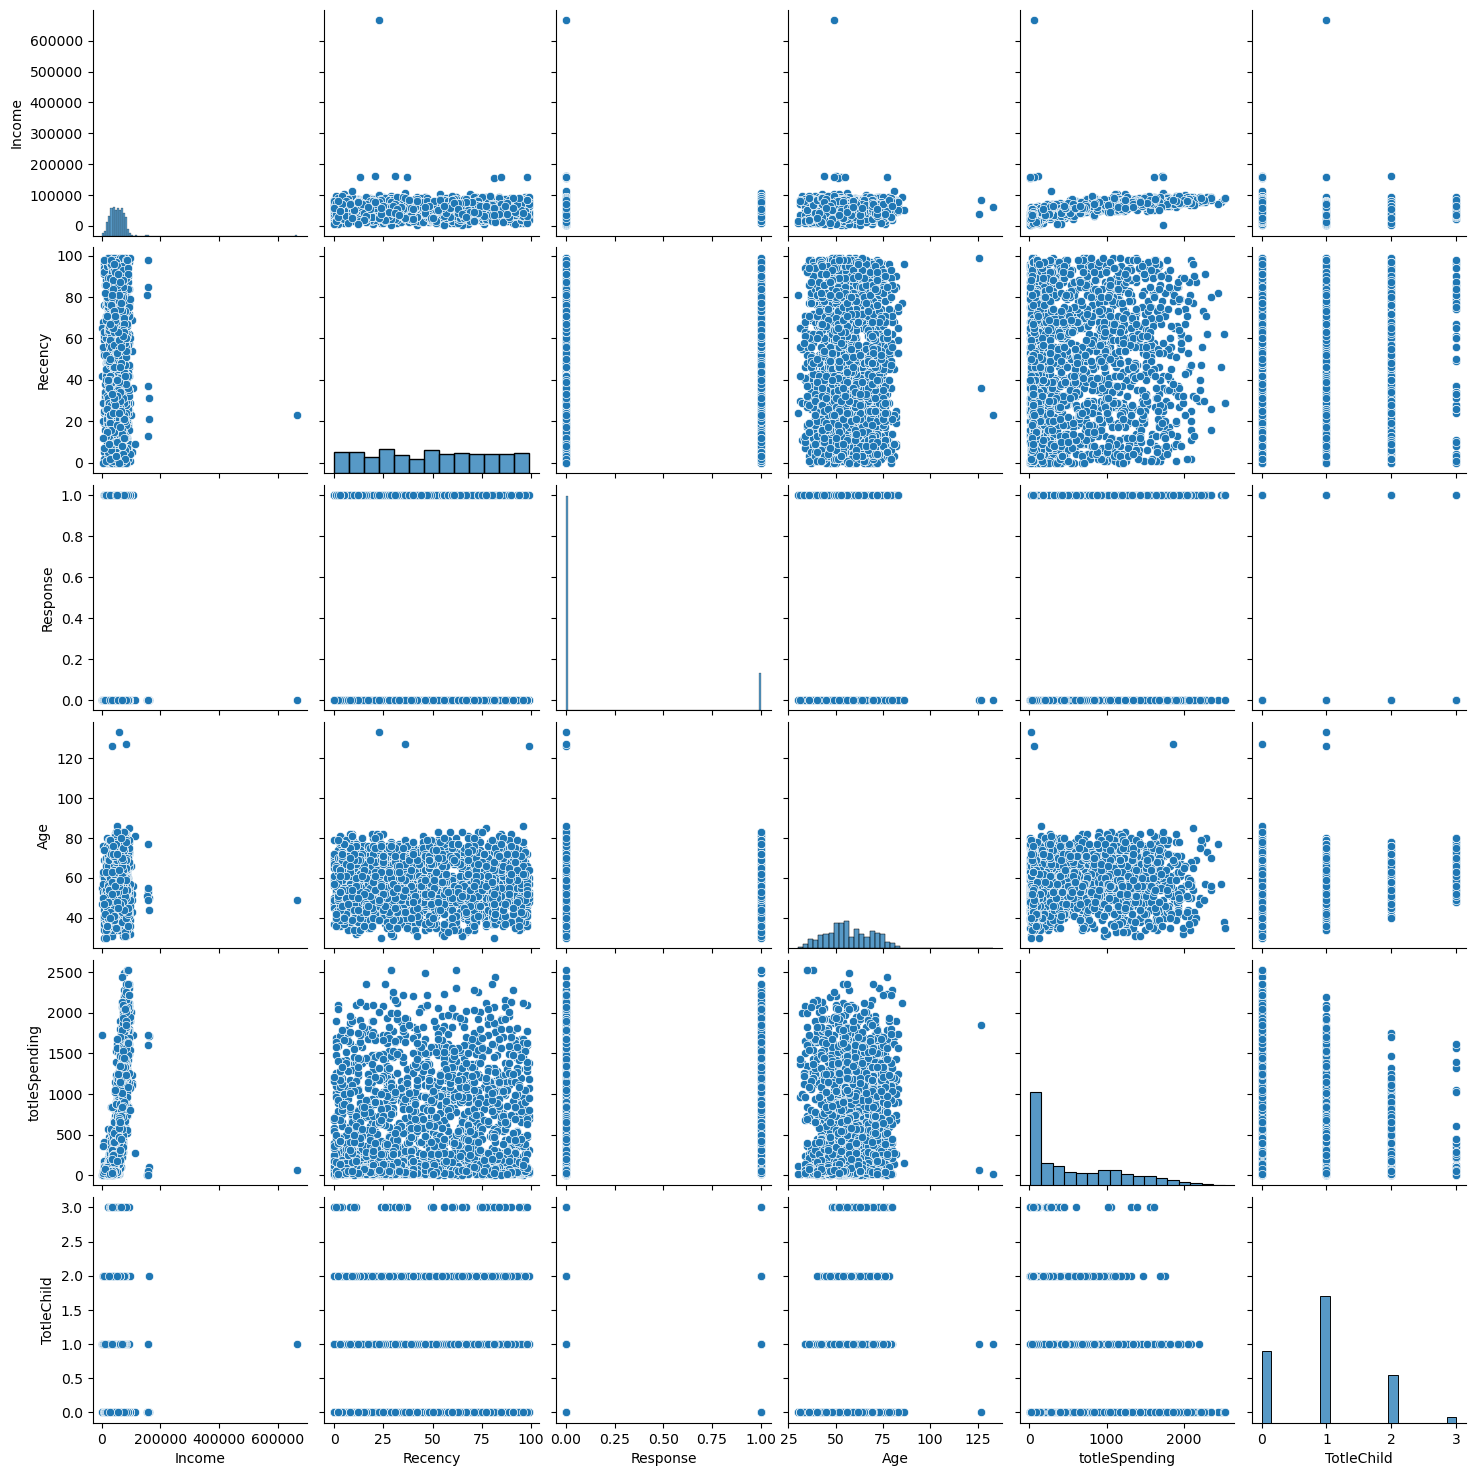

In [27]:
cols=["Income","Recency","Response","Age","totleSpending","TotleChild"]

#relative plots
sns.pairplot(df[cols])

In [28]:
#remove the outlier
print("Data with outliers:",len(df))

Data with outliers: 2240


In [29]:
#keep age in range age<90
df=df[df["Age"]<90]

In [30]:
#keep income<600000
df=df[df["Income"]<600000]

In [31]:
print("Data without outliers:",len(df))

Data without outliers: 2236


Coorelation

In [32]:
corr=df.corr(numeric_only=True)

In [33]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

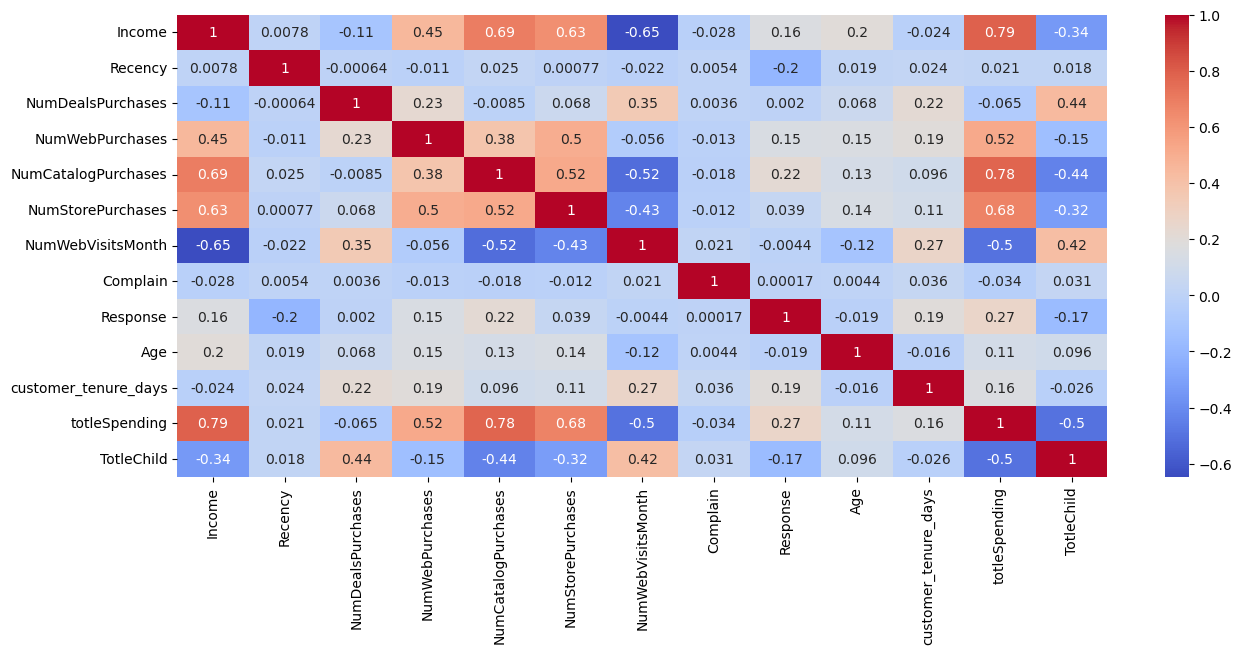

In [34]:
plt.figure(figsize=(15,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

Encoding

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
ohe=OneHotEncoder()
cols=["Education","living_with"]

encoded_cols=ohe.fit_transform(df[cols])

In [37]:
#transform in dataframe
enc_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cols),index=df.index)

In [38]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_undergraduate,living_with_Alone,living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [39]:
df_encoded=pd.concat([df.drop(columns=cols),enc_df],axis=1)

In [40]:
df_encoded.head(10)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild,Education_Graduate,Education_Postgraduate,Education_undergraduate,living_with_Alone,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
5,62513.0,16,2,6,4,10,6,0,0,59,293,716,1,0.0,1.0,0.0,0.0,1.0
6,55635.0,34,4,7,3,7,6,0,0,55,593,590,1,1.0,0.0,0.0,1.0,0.0
7,33454.0,32,2,4,0,4,8,0,0,41,417,169,1,0.0,1.0,0.0,0.0,1.0
8,30351.0,19,1,3,0,2,9,0,1,52,388,46,1,0.0,1.0,0.0,0.0,1.0
9,5648.0,68,1,1,0,0,20,0,0,76,108,49,2,0.0,1.0,0.0,0.0,1.0


Scaling 

In [41]:
from sklearn.preprocessing import StandardScaler
X=df_encoded

In [42]:
scaler=StandardScaler()
X_scale=scaler.fit_transform(X)

In [43]:
X_scale

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

Visualize

In [44]:
X_scale.shape

(2236, 18)

In [45]:
#2d 
from sklearn.decomposition import PCA

In [46]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(X_scale)

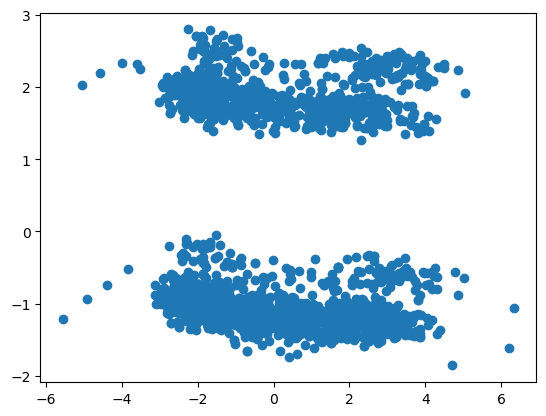

In [47]:
plt.scatter(
  x_pca[:,0],x_pca[:,1]
)

In [48]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

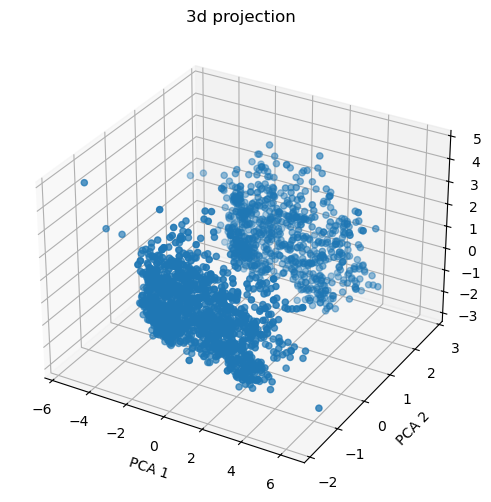

In [49]:
#3d plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    x_pca[:,0],x_pca[:,1],x_pca[:,2]
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d projection")

Analyze K value

1)Elbow Method

In [50]:
from sklearn.cluster import KMeans

wcss=[]
for i in range(1,11):
    kmean=KMeans(n_clusters=i,random_state=42)
    kmean.fit_predict(x_pca)
    wcss.append(kmean.inertia_)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [51]:
wcss

[18093.25779332454,
 10760.843401758226,
 8830.288717243046,
 6650.969417658873,
 5006.161168001195,
 4396.308699108108,
 3857.6330644275695,
 3207.0576242216584,
 3025.2232554325815,
 2651.4429891061445]

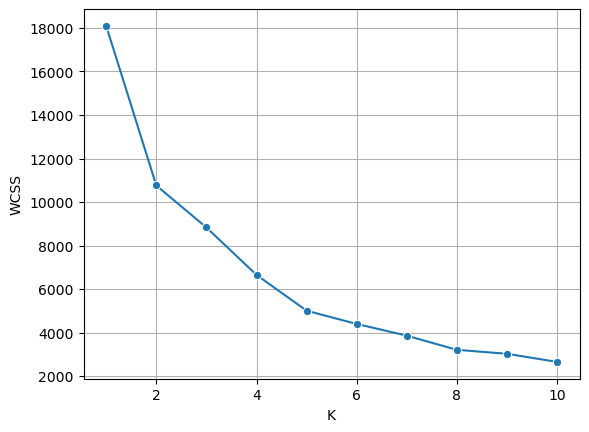

In [52]:
#graph
sns.lineplot(
    x=range(1,11),
    y=wcss,
    marker="o"
)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.grid()

In [53]:
#silhouette score
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    labels=kmean.fit_predict(x_pca)
    ss.append(silhouette_score(x_pca,labels))

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [54]:
ss

[0.37157939079762237,
 0.3076881927474245,
 0.35809961595961043,
 0.40001521476609386,
 0.3992918389855379,
 0.40262087405564545,
 0.40508588286885105,
 0.40118897046491864,
 0.4029117336478344]

Text(0, 0.5, 'silhouette score')

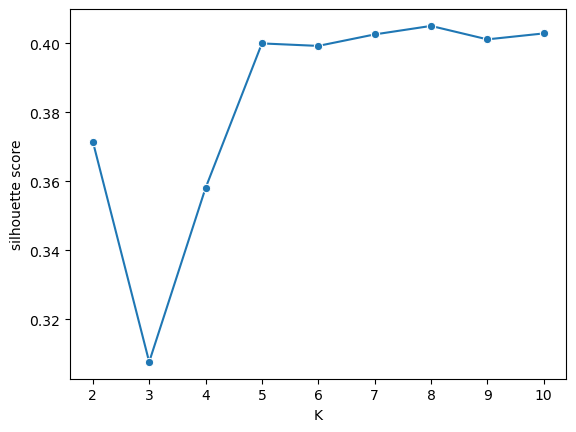

In [55]:
sns.lineplot(
    x=range(2,11),
    y=ss,
    marker="o"
)
plt.xlabel("K")
plt.ylabel("silhouette score")

Text(0, 0.5, 'SS')

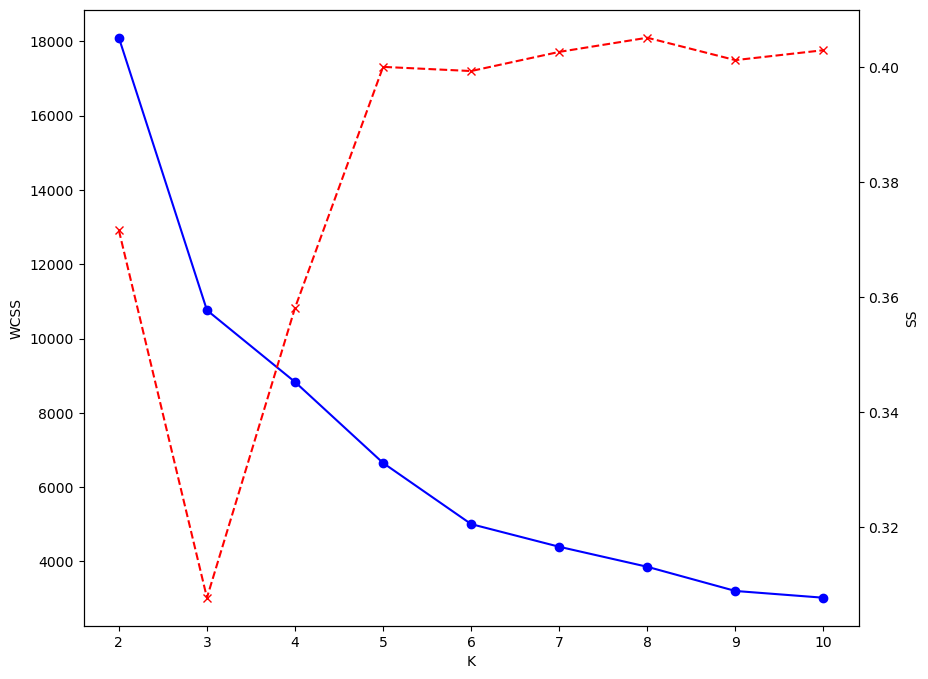

In [56]:
#combain plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,ss,marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

Clustering

In [57]:
#kmean
kmean=KMeans(n_clusters=4,random_state=42)
lables=kmean.fit_predict(x_pca)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Text(0.5, 0.92, '3d projection')

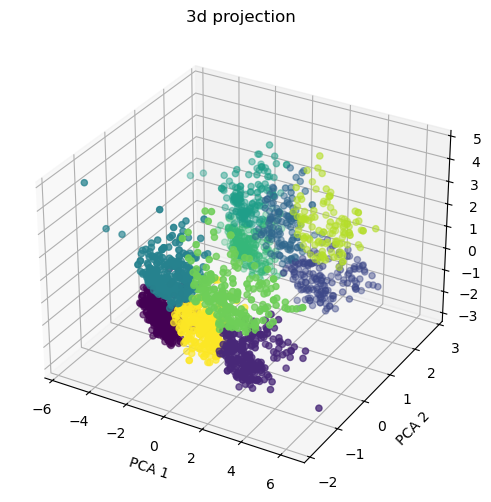

In [58]:
#vizulize in 3d
#3d plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d projection")

In [59]:
#agglowromative clustering
from sklearn.cluster import AgglomerativeClustering

In [60]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
label_agg=agg_clf.fit_predict(x_pca)

Text(0.5, 0.92, '3d projection')

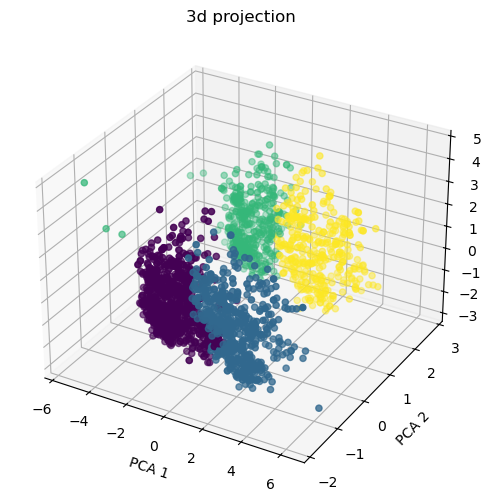

In [61]:
#vizulize in 3d
#3d plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    x_pca[:,0],x_pca[:,1],x_pca[:,2],c=label_agg
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d projection")

Characterization of clusters

In [73]:
X["Cluster"]=label_agg

In [74]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,totleSpending,TotleChild,Education_Graduate,Education_Postgraduate,Education_undergraduate,living_with_Alone,living_with_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

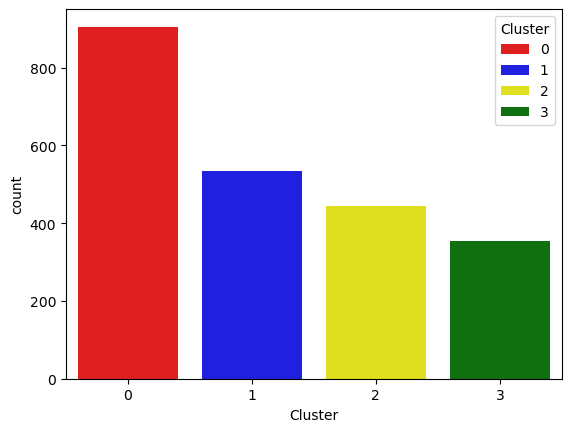

In [75]:
#Graph of all clusters
pal=["red","blue","yellow","green"]
sns.countplot(
    x=X["Cluster"],
    palette=pal,hue=X["Cluster"]
)

<Axes: xlabel='totleSpending', ylabel='Income'>

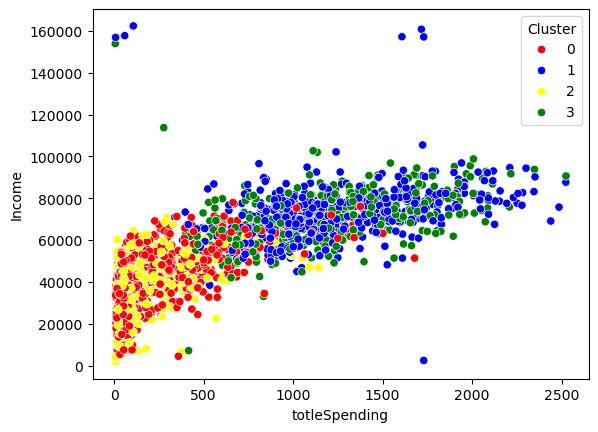

In [76]:
#cheak income and spending pattern
sns.scatterplot(
    x=X["totleSpending"],
    y=X["Income"],
    hue=X["Cluster"],palette=pal
)

Cluster Summary

In [82]:
cluster_summary=X.groupby("Cluster").mean()

print("Cluster summary")
print(cluster_summary)

Cluster summary
               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  customer_tenure_days  totleSpending  Tot